## The multiperiod binomial model and Monte Carlo method

Consider a stock at time $n$ trading at price $S_n$ and that can take only two (non-negative) values at time $n+1$. Upon additionally defining a time-zero price $S_0$ and multiplicative scaling factors for these upwards and downwards moves, say $u,d \, (u > d)$ respectively, we can interpet the path of such a stock's price as being determined entirely by a sequence of tosses of a coin of fixed probabilities. Where the stock moves upwards (to $S_0u$) if the result of the toss is heads and downwards (to $S_0d$) if the result is tails.

Crucially, when these probabilities are taken to be the _risk-neutral probabilities_, we obtain the multiperiod binomial asset pricing model originally formalised by Cox, Ross, and Rubinstein [1].

In this context, _risk-neutral_ describes market participants not requiring compensation for risk, nor expressing willingness to pay extra for it. This assumption allows use of a replication argument since both stocks and money market instruments are assumed to generate the same return, equal to that of the risk-free rate. In particular, _risk-neutral probabilities_ describe the set of probabilities that under which the stocks expected return is exactly equal to the risk-free rate, denote it $r$.

One can simulate paths of an underlying assumed to follow this binomial model by taking random samples from a binomial distribution with probability of success equal to this risk-neutral probability of flipping a head. Repeating this for many paths — what is known as Monte Carlo simulation — one can approximate the fair time-zero price of a derivatives contract on this underlying by simply discounting back the average payoff from these paths. Indeed, this is done below for a vanilla European call option, and the Monte Carlo price compared to the analytical solution, obtained via a backward induction approach [2, Thm 1.2.2].

Analytical time-zero price: 16.04
Monte Carlo time-zero price: 15.18


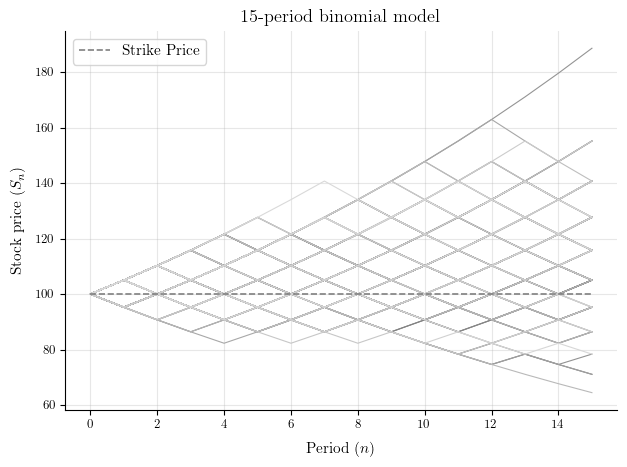

In [2]:
#VANILLA BINOMIAL
import numpy as np
import matplotlib.pyplot as plt
from derivativesPricing.stochasticProcesses import binomial
plt.rcParams.update({"text.usetex":True,
                     "font.family":"serif",
                     "font.size":11,
                     "axes.labelsize": 11,
                     "xtick.labelsize": 9,
                     "ytick.labelsize": 9,
                     "legend.fontsize": 11,
                     "lines.markersize": 2,
                     "axes.spines.top":False,
                     "axes.spines.right":False
})

#PARAMETERS
s0 = 100 #time-zero price of underlying
X = 100 #strike price of derivatives contract
r = 0.01 #one period risk-free rate
N = 15 #number of periods
u = 1.05 #multiplicative factor for an upwards move
d = 1/u #multiplicative factor for a downwards move
npaths = 100 #number of paths to simulate

#ANALYTICAL
p = (1+r-d)/(u-d) #risk-neutral probability of a head, as defined in the thm
vn = np.array([max(0, s0*(u**k)*d**(N-k)-X) for k in range(0,N+1)]) #terminal payoff array

for n in range(N,0,-1): #backwards induction
    vn = np.array([max(0, (p*vn[k+1] + (1-p)*vn[k])/(1+r)) for k in range(0,n)])
v0A = vn[0]

#MONTE CARLO
walks = binomial(s0, p, u, d, npaths, N)
v0S = np.maximum(0, walks[:,-1]-X).mean()/(1+r)**N

print(f"Analytical time-zero price: {np.round(v0A, 2)}\n"
      f"Monte Carlo time-zero price: {np.round(v0S, 2)}")

#PATH PLOT
greys = np.linspace(0.35,0.85,npaths)
fig, ax = plt.subplots()
for i,g in enumerate(greys):
    ax.plot(walks[i], color = str(g), linewidth = 0.8)
strike = ax.hlines(X, 0, N, "grey", linestyles = "--", linewidth = 1.2)
ax.set_xlabel(r"Period ($n$)", labelpad = 8), ax.set_ylabel(r"Stock price ($S_n$)", labelpad = 8), ax.set_title(f"{N}-period binomial model")
ax.xaxis.tick_bottom()
ax.grid(True, alpha = 0.3)
ax.legend(handles = [strike], labels = ["Strike Price"], loc = "best")
fig.tight_layout();

Above, we simulated 100 paths only to keep the plot presentable; for any practical application, one would simulate a number of paths many orders of magnitude greater. Indeed, as the number of paths approaches infinity, by the Strong Law of Large Numbers, the Monte Carlo approximation will tend towards the analytical solution. Moreover, for any standard Monte Carlo method the relative mean square error (RMSE) converges at a rate of $\mathcal{O}(M^{-1/2})$ [3, Chapter 1.1.1], where $M$ is the number of paths. That is, to reduce the error by one decimal place, one must in theory increase the number of paths by two orders of magnitude. Below, this convergence to the analytical solution is showcased empirically in terms of the RMSE, using the same parameters as defined previously.

                 Mean $t_0$ price  Root mean square error
Number of paths                                          
3.0                     15.253411                8.658155
12.0                    15.788688                4.863276
52.0                    15.646946                2.004703
215.0                   16.322387                1.002002
879.0                   15.939448                0.532782
3593.0                  16.043880                0.298352
14677.0                 15.998666                0.139304
59948.0                 16.045471                0.066376
244843.0                16.023352                0.034780
1000000.0               16.024506                0.022793
inf                     16.035416                0.000000


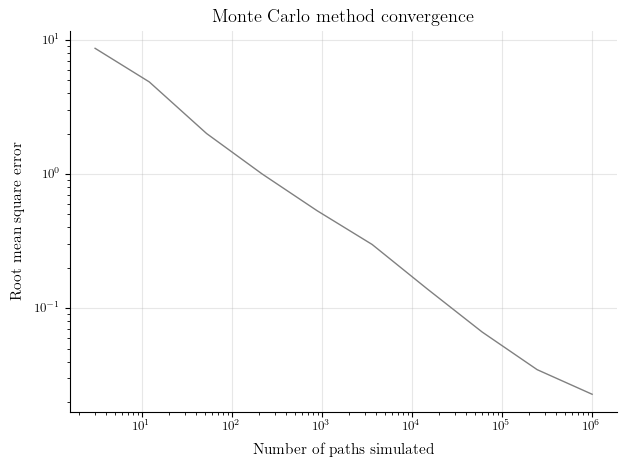

In [26]:
#VANILLA CONVERGENCE
from pandas import DataFrame

#REPEATED MONTE CARLO
logpaths = np.logspace(1/2, 6, num = 10)
n_repeats_arr = np.logspace(1, 2, num = 10)
dfrows = []

for n_repeats, npaths in zip(n_repeats_arr[::-1], logpaths):
    v0S_repeats = []
    for _ in range(int(n_repeats)):
        walks = binomial(s0, p, u, d, int(npaths), N)
        v0S_repeats.append(np.maximum(0, walks[:,-1]-X).mean()/(1+r)**N)
    v0s_repeats = np.array(v0S_repeats)
    dfrows.append([int(npaths), np.mean(v0S_repeats), np.sqrt(np.mean((v0S_repeats-v0A)**2))])
dfrows.append([np.inf,v0A,0])

df = DataFrame(dfrows, columns = ["Number of paths", r"Mean $t_0$ price", "Root mean square error"])
print(df.set_index("Number of paths"))

#ERROR PLOT
fig, ax = plt.subplots()
ax.loglog(df["Number of paths"],df["Root mean square error"], linewidth = 1, color = "grey")
ax.set_xlabel("Number of paths simulated", labelpad = 8), ax.set_ylabel("Root mean square error", labelpad = 8), ax.set_title("Monte Carlo method convergence")
ax.xaxis.tick_bottom()
ax.grid(True, alpha = 0.3)
fig.tight_layout()

We now consider an arithmetic Asian option; these are path-dependent derivatives that use the arithmetic mean price of the underlying over the life of the contract, as opposed to simply the price at expiration. Importantly, closed form solutions for pricing such arithmetic Asians do not generally exist [4] and analytical solutions via a backward induction approach quickly become unobtainable as the state space grows exponentially. As such, the Monte Carlo method described previously becomes our main method by which to efficiently price these contracts for any practical application. The implementation of such method is virtually unchanged from that for the vanilla option, indeed the only difference is to that of the payoff structure; now summarised as:$$\begin{matrix} \text{call payoff}~= \max (0, S_{\text{avg}}-X)~\text{and}\\ \text{put payoff}~= \max (0, X-S_{\text{avg}}) \hfill \end{matrix}$$

Monte Carlo time-zero price: 3.52


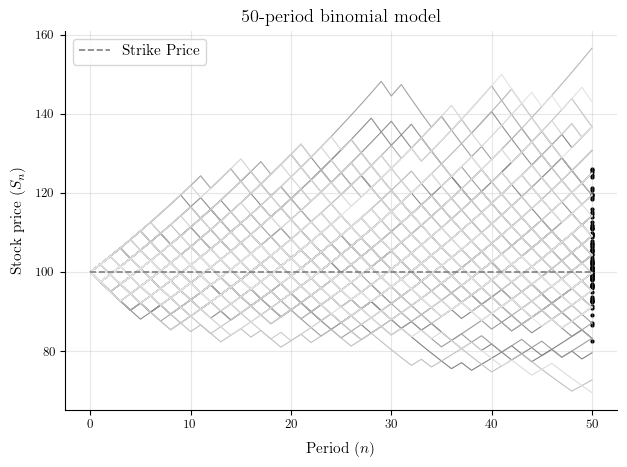

In [27]:
#ARITHMETIC ASIAN BINOMIAL

#PARAMETERS
s0 = 100 #time-zero price of underlying
X = 100 #strike price of derivatives contract
r = 0.01 #one period risk-free rate
N = 50 #number of periods
u = 1.02 #multiplicative factor for an upwards move
d = 0.975 #multiplicative factor for a downwards move
npaths = 100 #number of paths to simulate

#MONTE CARLO
walks = binomial(s0, p, u, d, npaths, N)
arithmetic_means = walks.mean(axis = 1) #we include start and end times, t_0 and t_N respectively, in our mean calculation
v0Asian = np.maximum(0, arithmetic_means-X).mean()/(1+r)**N #payoff structure: V = max(0, S_{avg}-X)

print(f"Monte Carlo time-zero price: {np.round(v0Asian, 2)}")

#PATH PLOT
greys = np.linspace(0.5,0.9,npaths)
fig, ax = plt.subplots()
for i,g in enumerate(greys):
    ax.plot(walks[i], color = str(g), linewidth = 0.8)
means = ax.scatter(np.full(npaths, fill_value = N), arithmetic_means, c = ["black"])
strike = ax.hlines(X, 0, N, "grey", linestyles = "--", linewidth = 1.2)
ax.set_xlabel(r"Period ($n$)", labelpad = 8), ax.set_ylabel(r"Stock price ($S_n$)", labelpad = 8), ax.set_title(f"{N}-period binomial model")
ax.xaxis.tick_bottom()
ax.grid(True, alpha = 0.3)
ax.legend(handles = [strike], labels = ["Strike Price"], loc = "best")
fig.tight_layout()

Despite not having an analytical solution for which to compare against, we can still observe convergence — again by the Strong Law of Large Numbers — of the Monte Carlo method for our arithmetic Asian option. Indeed, this convergence is demonstrated below by repeated simulation for logarithmically spaced values of _npaths_ from $10^{1/2}$ to $10^7$.

In [28]:
#ARITHMETIC ASIAN CONVERGENCE

#REPEATED MONTE CARLO
logpaths = np.logspace(1/2,7, num = 10)
n_repeats_arr = np.logspace(1,2, num = 10)
dfrows = []

for n_repeats, npaths in zip(n_repeats_arr[::-1], logpaths):
    v0Asian_repeats = []
    for _ in range(int(n_repeats)):
        walks = binomial(s0, p, u, d, int(npaths), N)
        arithmetic_means = walks.mean(axis = 1)
        v0Asian_repeats.append(np.maximum(0, arithmetic_means-X).mean()/(1+r)**N)
    dfrows.append([int(npaths), np.mean(v0Asian_repeats)])

df = DataFrame(dfrows, columns = ["npaths", r"Mean MC $t_0$ price"])
df.set_index("npaths", inplace = True)
df[r"Mean MC $t_0$ price"] = df[r"Mean MC $t_0$ price"].map("{:.6f}".format)
print(df)

         Mean MC $t_0$ price
npaths                      
3                   3.499840
16                  3.643190
87                  3.643577
464                 3.664039
2448                3.661697
12915               3.675593
68129               3.677767
359381              3.679418
1895735             3.677203
10000000            3.677286


## References

[1] John C. Cox, Stephen A. Ross, and Mark Rubinstein. “Option pricing:
A simplified approach”. In: Journal of Financial Economics 7.3 (1979),
pp. 229–263. issn: 0304-405X. doi: https://doi.org/10.1016/0304-405X(79)90015-1.

[2] Steven E. Shreve. Stochastic Calculus for Finance I: The Binomial Asset
Pricing Model. Springer, 2004. ISBN: 978-0387249681.

[3] Paul Glasserman. Monte Carlo Methods in Financial Engineering. Springer, 2013. ISBN: 978-0387216171.

[4] A.G.Z. Kemna and A.C.F. Vorst. “A pricing method for options based on
average asset values”. In: Journal of Banking and Finance 14.1 (1990),
pp. 113–129. issn: 0378-4266. doi: https://doi.org/10.1016/0378-4266(90)90039-5.